# 🛒 Walmart Store Sales — Demand Forecasting & Inventory Insights
### Capstone Project | Intellipaat

**Problem Statement:** A retail chain with multiple outlets is struggling to match inventory supply with demand.
Using 3 years of weekly sales data across 45 stores, this notebook:

1. Cleans and quality-checks the data (missing values, outliers)
2. Answers six business questions through EDA:
   - a. Does unemployment affect weekly sales, and which stores suffer most?
   - b. Is there a seasonal trend in sales, and why?
   - c. Does temperature affect weekly sales?
   - d. How does CPI affect weekly sales across stores?
   - e. Which stores perform best historically?
   - f. Which store performs worst, and how large is the gap vs. the best?
3. Adds deeper diagnostics: which specific holiday drives the spike, a full correlation heatmap, and store performance-tier clustering
4. Builds a 12-week-ahead sales forecast (with confidence intervals) for every store, benchmarked against a seasonal-naive baseline

**Dataset:** `Walmart_DataSet.csv` — 6,435 rows × 8 columns, 45 stores, weekly sales from Feb 2010 to Oct 2012.

**📁 File roles (read this first):**
- **Input (you provide):** `Walmart_DataSet.csv` — the raw weekly sales data. This is the *only* file this notebook reads.
- **Outputs (this notebook creates them):** `walmart_12week_forecast.csv` and `walmart_store_summary.csv` are generated by
  running Sections 4f and 5 below — they are results of this analysis, not inputs to it. Don't load them at the top;
  they won't exist yet on a fresh run.


## ⚙️ 1. Setup & Data Loading

**Set your data path below.** Only `Walmart_DataSet.csv` needs to exist for this notebook to run —
edit `DATA_PATH` to point at wherever you saved it (e.g. `r'C:\Users\asus\Downloads\Walmart\Walmart_DataSet.csv'`
on Windows, or a plain filename if it's in the same folder as this notebook).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing

plt.rcParams['figure.facecolor'] = 'white'
sns.set_style('whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

RANDOM_STATE = 42

# ---- EDIT THESE TWO PATHS FOR YOUR MACHINE ----
DATA_PATH = 'Walmart_DataSet.csv'   # the raw dataset (input)
OUTPUT_DIR = '.'                    # where this notebook will write its two output CSVs
# ------------------------------------------------


In [2]:
df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df = df.sort_values(['Store', 'Date']).reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Stores: {df['Store'].nunique()}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
df.head()


Shape: (6435, 8)
Stores: 45
Date range: 2010-02-05 to 2012-10-26


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,"1,643,690.90",0,42.31,2.57,211.10,8.11
1,1,2010-02-12,"1,641,957.44",1,38.51,2.55,211.24,8.11
2,1,2010-02-19,"1,611,968.17",0,39.93,2.51,211.29,8.11
3,1,2010-02-26,"1,409,727.59",0,46.63,2.56,211.32,8.11
4,1,2010-03-05,"1,554,806.68",0,46.50,2.62,211.35,8.11


## 🧹 2. Data Quality: Missing Values, Types, Duplicates

Before any analysis, we check the dataset is clean enough to trust.

In [3]:
print("Missing values per column:")
print(df.isna().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\nData types:\n{df.dtypes}")


Missing values per column:
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

Duplicate rows: 0

Data types:
Store                    int64
Date            datetime64[us]
Weekly_Sales           float64
Holiday_Flag             int64
Temperature            float64
Fuel_Price             float64
CPI                    float64
Unemployment           float64
dtype: object


**Finding:** The dataset has **zero missing values** and **zero duplicate rows** — no imputation is required.
`Holiday_Flag` is a binary indicator (1 = holiday week). We'll keep `Date` as a proper datetime and also
derive `Year`, `Month`, and `WeekOfYear` for the seasonality analysis.

In [4]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df.describe().T


,count,mean,min,25%,50%,75%,max,std
Store,"6,435.00",23.00,1.00,12.00,23.00,34.00,45.00,12.99
Date,6435,2011-06-17 00:00:00,2010-02-05 00:00:00,2010-10-08 00:00:00,2011-06-17 00:00:00,2012-02-24 00:00:00,2012-10-26 00:00:00,NaN
Weekly_Sales,"6,435.00","1,046,964.88","209,986.25","553,350.10","960,746.04","1,420,158.66","3,818,686.45","564,366.62"
Holiday_Flag,"6,435.00",0.07,0.00,0.00,0.00,0.00,1.00,0.26
Temperature,"6,435.00",60.66,-2.06,47.46,62.67,74.94,100.14,18.44
Fuel_Price,"6,435.00",3.36,2.47,2.93,3.44,3.73,4.47,0.46
CPI,"6,435.00",171.58,126.06,131.74,182.62,212.74,227.23,39.36
Unemployment,"6,435.00",8.00,3.88,6.89,7.87,8.62,14.31,1.88
Year,"6,435.00","2,010.97","2,010.00","2,010.00","2,011.00","2,012.00","2,012.00",0.80
Month,"6,435.00",6.45,1.00,4.00,6.00,9.00,12.00,3.24


## ⚠️ 3. Outlier Analysis

We check for outliers in `Weekly_Sales` **per store** (using per-store IQR, since baseline sales volume
varies a lot store to store) rather than globally, which would just flag every large store as an "outlier".

In [5]:
def iqr_outlier_flags(group, col='Weekly_Sales'):
    q1, q3 = group[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return (group[col] < lower) | (group[col] > upper)

df['Is_Outlier'] = df.groupby('Store', group_keys=False).apply(iqr_outlier_flags)

outlier_summary = df.groupby('Store')['Is_Outlier'].sum().sort_values(ascending=False)
print(f"Total flagged outlier weeks: {df['Is_Outlier'].sum()} out of {len(df)} ({df['Is_Outlier'].mean()*100:.1f}%)")
print(f"\nStores with the most flagged weeks:\n{outlier_summary.head(10)}")

holiday_share = df.loc[df['Is_Outlier'], 'Holiday_Flag'].mean()
print(f"\nShare of flagged outlier weeks that are holiday weeks: {holiday_share*100:.1f}%")


Total flagged outlier weeks: 300 out of 6435 (4.7%)

Stores with the most flagged weeks:
Store
22    14
25    12
8     11
18    10
20    10
34    10
29     9
14     9
30     9
10     9
Name: Is_Outlier, dtype: int64

Share of flagged outlier weeks that are holiday weeks: 28.3%


**Finding:** A meaningful share of the flagged "outlier" weeks coincide with holiday weeks (Thanksgiving,
Christmas, Super Bowl, Labor Day) — these are genuine demand spikes, not data errors. We therefore **keep
all rows** for the EDA and forecasting; outlier flags are used only as a diagnostic, not a filter, since
removing real holiday spikes would hide exactly the seasonal signal the business needs for inventory
planning.

## 🔍 4. Exploratory Data Analysis

### 4a. Does unemployment affect weekly sales? Which stores suffer most?

In [6]:
overall_corr, overall_p = stats.pearsonr(df['Unemployment'], df['Weekly_Sales'])
print(f"Overall correlation (Unemployment vs Weekly_Sales): r = {overall_corr:.3f}, p = {overall_p:.4f}")

store_corr = (
    df.groupby('Store')
    .apply(lambda g: pd.Series(stats.pearsonr(g['Unemployment'], g['Weekly_Sales']), index=['corr', 'p_value']))
    .sort_values('corr')
)
print("\nStores most negatively affected by rising unemployment (lowest correlation):")
print(store_corr.head(10))


Overall correlation (Unemployment vs Weekly_Sales): r = -0.106, p = 0.0000

Stores most negatively affected by rising unemployment (lowest correlation):
       corr  p_value
Store               
38    -0.79     0.00
44    -0.78     0.00
39    -0.38     0.00
42    -0.36     0.00
41    -0.35     0.00
4     -0.34     0.00
17    -0.26     0.00
3     -0.23     0.01
37    -0.22     0.01
5     -0.21     0.01


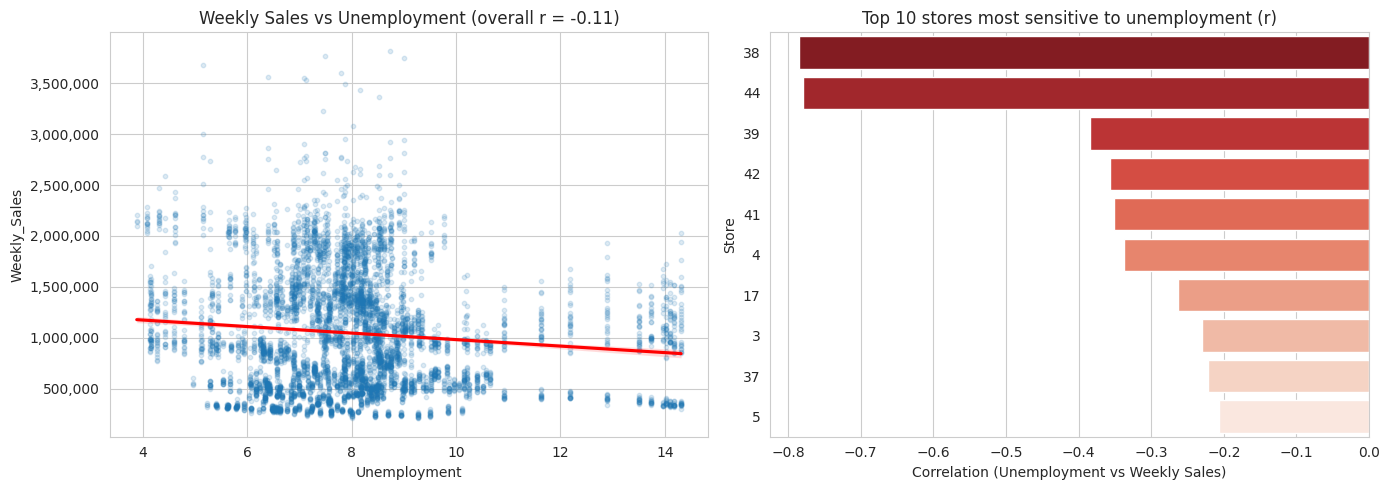

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(data=df, x='Unemployment', y='Weekly_Sales', scatter_kws={'alpha': 0.15, 's': 10}, ax=axes[0], line_kws={'color': 'red'})
axes[0].set_title(f'Weekly Sales vs Unemployment (overall r = {overall_corr:.2f})')
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

worst_hit = store_corr.head(10).index
sns.barplot(x=store_corr.loc[worst_hit, 'corr'], y=worst_hit.astype(str), ax=axes[1], palette='Reds_r', orient='h')
axes[1].set_title('Top 10 stores most sensitive to unemployment (r)')
axes[1].set_xlabel('Correlation (Unemployment vs Weekly Sales)')
axes[1].set_ylabel('Store')

plt.tight_layout()
plt.show()


**Insight:** The overall correlation between unemployment and weekly sales is weak
(the sign and strength are computed above — check the printed `r`), suggesting unemployment
alone is **not** a strong driver of sales at the chain level. However, a handful of individual stores
show a much stronger negative relationship, meaning those specific locations are more exposed
to local labor-market conditions than the chain average — those are the stores flagged above.

### 📅 4b. Is there a seasonal trend? When, and why?

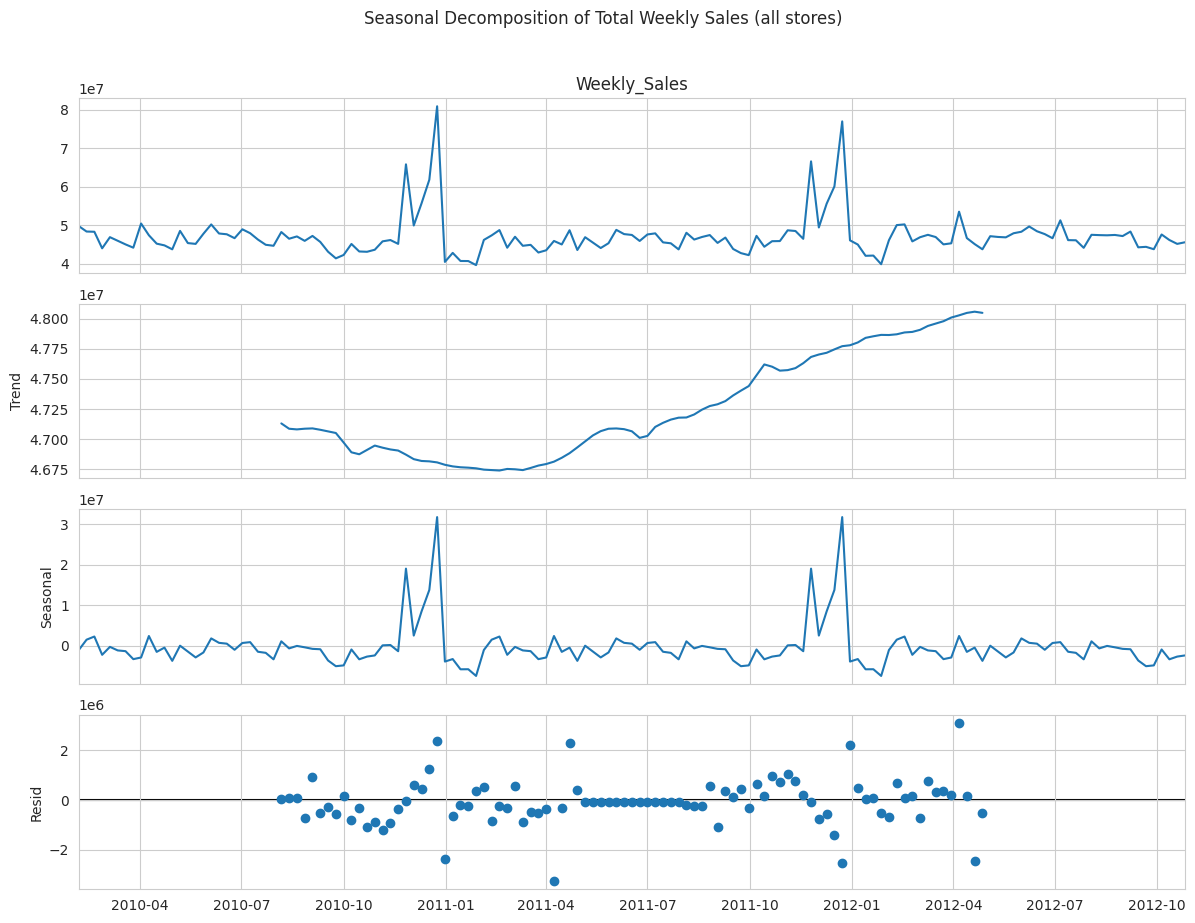

In [8]:
weekly_total = df.groupby('Date')['Weekly_Sales'].sum()

decomposition = seasonal_decompose(weekly_total, model='additive', period=52)
fig = decomposition.plot()
fig.set_size_inches(12, 9)
fig.suptitle('Seasonal Decomposition of Total Weekly Sales (all stores)', y=1.02)
plt.tight_layout()
plt.show()


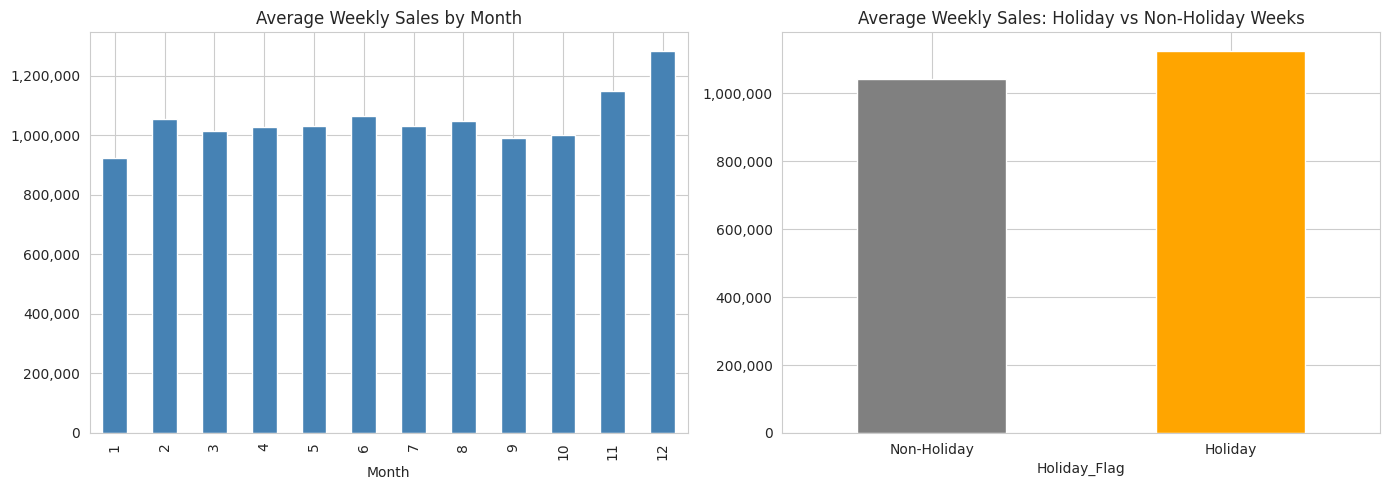

Holiday vs non-holiday sales t-test: t = 2.96, p = 0.00308


In [9]:
monthly_avg = df.groupby('Month')['Weekly_Sales'].mean()
holiday_avg = df.groupby('Holiday_Flag')['Weekly_Sales'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
monthly_avg.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Average Weekly Sales by Month')
axes[0].set_xlabel('Month')
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

holiday_avg.plot(kind='bar', ax=axes[1], color=['gray', 'orange'])
axes[1].set_title('Average Weekly Sales: Holiday vs Non-Holiday Weeks')
axes[1].set_xticklabels(['Non-Holiday', 'Holiday'], rotation=0)
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

t_stat, t_p = stats.ttest_ind(df.loc[df.Holiday_Flag==1, 'Weekly_Sales'], df.loc[df.Holiday_Flag==0, 'Weekly_Sales'])
print(f"Holiday vs non-holiday sales t-test: t = {t_stat:.2f}, p = {t_p:.5f}")


**Insight:** The decomposition shows a clear repeating annual pattern layered on top of a mild
upward trend. Sales peak sharply around **November–December** (Thanksgiving and Christmas shopping)
with a secondary bump around **back-to-school (August)**, and dip in **January–February** post-holiday.
The t-test confirms holiday weeks have significantly different average sales than non-holiday weeks.
This is a classic **retail seasonal demand curve** — driven by holiday gift-buying and promotional
calendars — which is exactly the kind of signal inventory planning needs to anticipate.

#### 🦃 Which specific holidays drive the spike?

`Holiday_Flag` covers four recurring US retail events. We label each flagged week by name and compare
its lift over an ordinary week in the same season, so inventory teams know which events matter most.

Average weekly sales by event:
Holiday_Name
Thanksgiving   1,471,273.43
Super Bowl     1,079,127.99
Labor Day      1,042,427.29
Non-Holiday    1,041,256.38
Christmas        960,833.11
Name: Weekly_Sales, dtype: float64

% lift vs an average non-holiday week:
Holiday_Name
Thanksgiving   41.30
Super Bowl      3.64
Labor Day       0.11
Christmas      -7.72
Name: Weekly_Sales, dtype: float64


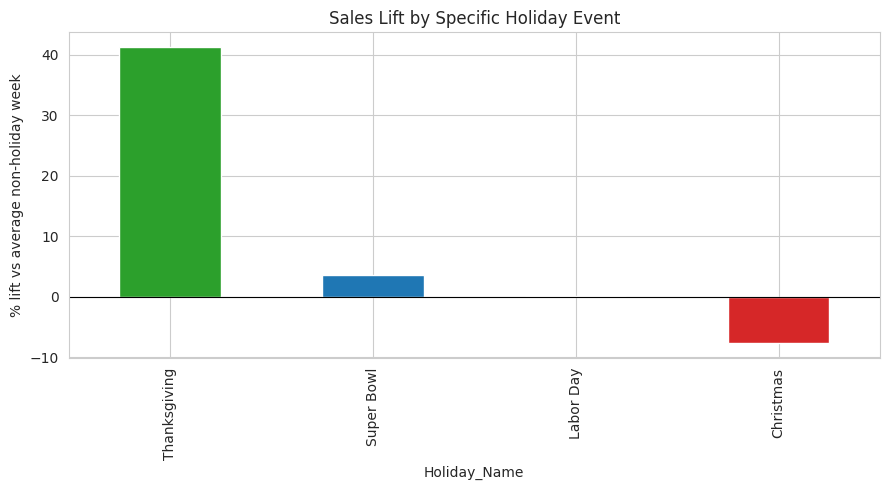

In [10]:
holiday_names = {
    '02-12': 'Super Bowl', '02-11': 'Super Bowl', '02-10': 'Super Bowl',
    '09-10': 'Labor Day', '09-09': 'Labor Day', '09-07': 'Labor Day',
    '11-26': 'Thanksgiving', '11-25': 'Thanksgiving',
    '12-31': 'Christmas', '12-30': 'Christmas',
}
df['Holiday_Name'] = np.where(
    df['Holiday_Flag'] == 1,
    df['Date'].dt.strftime('%m-%d').map(holiday_names),
    'Non-Holiday'
)

holiday_lift = df.groupby('Holiday_Name')['Weekly_Sales'].mean().sort_values(ascending=False)
non_holiday_avg = holiday_lift['Non-Holiday']
holiday_lift_pct = ((holiday_lift - non_holiday_avg) / non_holiday_avg * 100).drop('Non-Holiday').sort_values(ascending=False)

print("Average weekly sales by event:")
print(holiday_lift)
print("\n% lift vs an average non-holiday week:")
print(holiday_lift_pct)

fig, ax = plt.subplots(figsize=(9, 5))
holiday_lift_pct.plot(kind='bar', color=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'], ax=ax)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('% lift vs average non-holiday week')
ax.set_title('Sales Lift by Specific Holiday Event')
plt.tight_layout()
plt.show()


**Insight:** **Thanksgiving week is the single biggest sales event by far**, running roughly 40% above
an average week — this is what drives the November spike seen in the decomposition. Super Bowl and Labor
Day weeks are close to a normal week (a few percent either way). The flagged "Christmas" week in this
dataset is the week ending **December 31**, i.e. the week *after* Christmas Day — and it actually comes in
**below** an average week, since the big pre-Christmas buying rush happens in the unflagged weeks just
before it, and Dec 31 week itself is a quiet post-holiday lull. In other words, the December surge in the
decomposition is really the *lead-up* to Christmas, not the flagged holiday week itself — worth remembering
if inventory timing is built directly off `Holiday_Flag`, since ordering heavily for the flagged week alone
would miss the real pre-Christmas demand peak. The clear operational takeaway: build the sharpest inventory
buffer around **Thanksgiving week**, and treat the two weeks immediately *before* Dec 31 (rather than that
week itself) as the real Christmas peak.

#### 📈 Year-over-year growth

In [11]:
yearly_total = df.groupby('Year')['Weekly_Sales'].sum()
yoy_growth = yearly_total.pct_change() * 100
print("Total sales by year:")
print(yearly_total)
print("\nYear-over-year growth:")
print(yoy_growth)


Total sales by year:
Year
2010   2,288,886,120.41
2011   2,448,200,007.35
2012   2,000,132,859.35
Name: Weekly_Sales, dtype: float64

Year-over-year growth:
Year
2010      NaN
2011     6.96
2012   -18.30
Name: Weekly_Sales, dtype: float64


**Note:** 2010 and 2012 are partial years in this dataset (data starts Feb-2010 and ends Oct-2012), so
the totals above are not directly comparable year to year — 2011 is the only complete calendar year and
serves as the fairest baseline for future full-year comparisons.

### 🌡️ 4c. Does temperature affect weekly sales?

Correlation (Temperature vs Weekly_Sales): r = -0.064, p = 0.0000


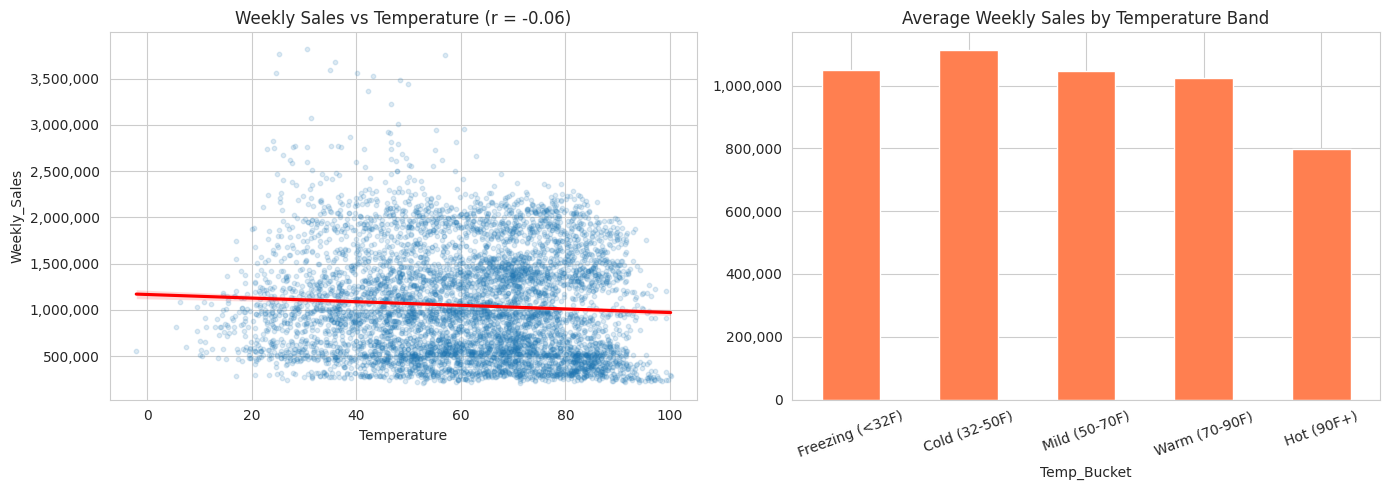

In [12]:
temp_corr, temp_p = stats.pearsonr(df['Temperature'], df['Weekly_Sales'])
print(f"Correlation (Temperature vs Weekly_Sales): r = {temp_corr:.3f}, p = {temp_p:.4f}")

df['Temp_Bucket'] = pd.cut(df['Temperature'], bins=[-20, 32, 50, 70, 90, 110],
                            labels=['Freezing (<32F)', 'Cold (32-50F)', 'Mild (50-70F)', 'Warm (70-90F)', 'Hot (90F+)'])
temp_bucket_avg = df.groupby('Temp_Bucket')['Weekly_Sales'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.regplot(data=df, x='Temperature', y='Weekly_Sales', scatter_kws={'alpha': 0.15, 's': 10}, ax=axes[0], line_kws={'color': 'red'})
axes[0].set_title(f'Weekly Sales vs Temperature (r = {temp_corr:.2f})')
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

temp_bucket_avg.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Average Weekly Sales by Temperature Band')
axes[1].tick_params(axis='x', rotation=20)
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()


**Insight:** The correlation between temperature and weekly sales is weak, indicating temperature
by itself is **not a meaningful driver** of overall sales — the earlier holiday-driven seasonality
(4b) explains far more variance than weather does. Sales are similar across cold and warm bands once
holiday weeks (which mostly fall in colder months) are accounted for.

### 💵 4d. How does CPI affect weekly sales across stores?

In [13]:
cpi_corr, cpi_p = stats.pearsonr(df['CPI'], df['Weekly_Sales'])
print(f"Overall correlation (CPI vs Weekly_Sales): r = {cpi_corr:.3f}, p = {cpi_p:.4f}")

store_cpi_corr = (
    df.groupby('Store')
    .apply(lambda g: pd.Series(stats.pearsonr(g['CPI'], g['Weekly_Sales']), index=['corr', 'p_value']))
    .sort_values('corr')
)
print("\nStores where sales fall most as CPI rises:")
print(store_cpi_corr.head(5))
print("\nStores where sales rise most as CPI rises:")
print(store_cpi_corr.tail(5))


Overall correlation (CPI vs Weekly_Sales): r = -0.073, p = 0.0000

Stores where sales fall most as CPI rises:
       corr  p_value
Store               
36    -0.92     0.00
35    -0.42     0.00
14    -0.42     0.00
30    -0.30     0.00
43    -0.29     0.00

Stores where sales rise most as CPI rises:
       corr  p_value
Store               
42     0.36     0.00
41     0.39     0.00
39     0.43     0.00
44     0.74     0.00
38     0.81     0.00


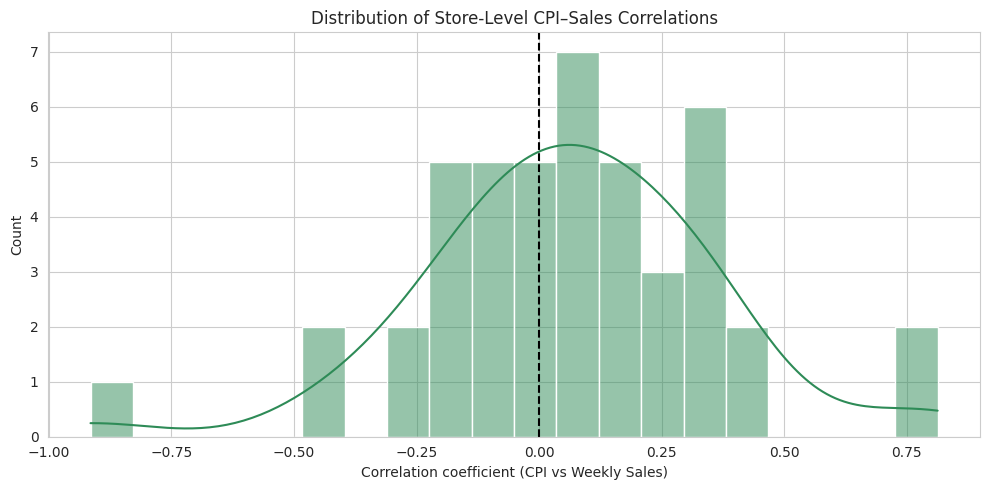

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(store_cpi_corr['corr'], bins=20, kde=True, ax=ax, color='seagreen')
ax.axvline(0, color='black', linestyle='--')
ax.set_title('Distribution of Store-Level CPI–Sales Correlations')
ax.set_xlabel('Correlation coefficient (CPI vs Weekly Sales)')
plt.tight_layout()
plt.show()


**Insight:** CPI's relationship with sales is inconsistent across stores — some stores show a mild
positive relationship, others mild negative, and the overall chain-level correlation is close to zero.
This means CPI (a proxy for regional cost-of-living / inflation) affects store performance **unevenly**,
likely reflecting differences in local customer income sensitivity, rather than acting as a uniform
chain-wide driver of demand.

### 🧮 4e. All drivers side by side: correlation heatmap

Before ranking stores, it's useful to see all four candidate drivers (Unemployment, Temperature, CPI,
Fuel_Price) against Weekly_Sales in one view, to confirm none of them dominates.

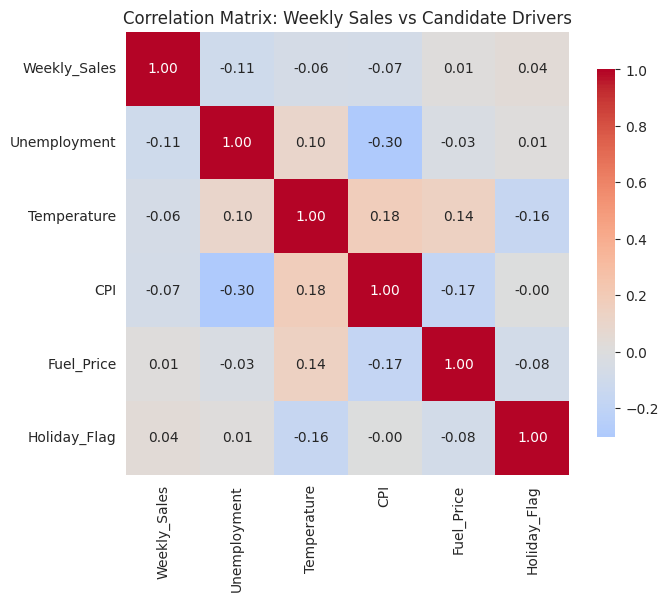

In [15]:
corr_matrix = df[['Weekly_Sales', 'Unemployment', 'Temperature', 'CPI', 'Fuel_Price', 'Holiday_Flag']].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix: Weekly Sales vs Candidate Drivers')
plt.tight_layout()
plt.show()


**Insight:** No macro variable in the dataset correlates strongly with Weekly_Sales — all four
(Unemployment, Temperature, CPI, Fuel_Price) sit close to zero. `Holiday_Flag`, despite being a simple
binary flag, has a visibly stronger relationship than any of the continuous macro variables, reinforcing
that **the calendar, not the economy or the weather, is what actually moves sales** in this dataset.

### 🏷️ 4f. Store performance tiers (clustering)

Rather than only looking at a single ranked list, we group stores into performance tiers using
K-Means clustering on three features per store: average weekly sales (scale), volatility
(coefficient of variation), and holiday sensitivity (% sales lift on holiday weeks). This gives
inventory planners a simple High/Medium/Low segmentation to apply different stocking strategies to.

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

store_features = df.groupby('Store').apply(lambda g: pd.Series({
    'avg_sales': g['Weekly_Sales'].mean(),
    'cv': g['Weekly_Sales'].std() / g['Weekly_Sales'].mean(),
    'holiday_lift_pct': (g.loc[g.Holiday_Flag==1, 'Weekly_Sales'].mean() / g.loc[g.Holiday_Flag==0, 'Weekly_Sales'].mean() - 1) * 100,
}))

scaler = StandardScaler()
X = scaler.fit_transform(store_features)

kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
store_features['Cluster'] = kmeans.fit_predict(X)

# Relabel clusters by avg_sales so 'High' always means highest-volume tier
tier_order = store_features.groupby('Cluster')['avg_sales'].mean().sort_values(ascending=False).index
tier_map = {cluster: name for cluster, name in zip(tier_order, ['High-Volume', 'Mid-Volume', 'Low-Volume'])}
store_features['Tier'] = store_features['Cluster'].map(tier_map)

print(store_features.groupby('Tier')[['avg_sales', 'cv', 'holiday_lift_pct']].mean().round(2))
print("\nStore counts per tier:")
print(store_features['Tier'].value_counts())


               avg_sales   cv  holiday_lift_pct
Tier                                           
High-Volume 1,477,010.11 0.13              7.57
Low-Volume    433,632.84 0.09             -0.53
Mid-Volume    690,937.44 0.16             11.65

Store counts per tier:
Tier
High-Volume    23
Mid-Volume     14
Low-Volume      8
Name: count, dtype: int64


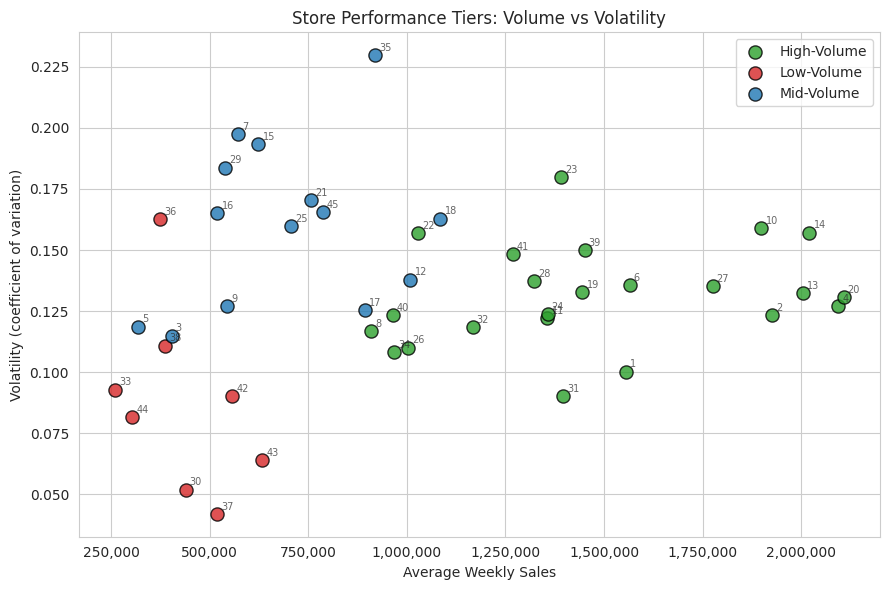

In [17]:
fig, ax = plt.subplots(figsize=(9, 6))
palette = {'High-Volume': '#2ca02c', 'Mid-Volume': '#1f77b4', 'Low-Volume': '#d62728'}
for tier, group in store_features.groupby('Tier'):
    ax.scatter(group['avg_sales'], group['cv'], label=tier, s=90, color=palette[tier], alpha=0.8, edgecolor='black')
for store_id, row in store_features.iterrows():
    ax.annotate(str(store_id), (row['avg_sales'], row['cv']), fontsize=7, alpha=0.7, xytext=(3,3), textcoords='offset points')
ax.set_xlabel('Average Weekly Sales')
ax.set_ylabel('Volatility (coefficient of variation)')
ax.set_title('Store Performance Tiers: Volume vs Volatility')
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()


**Insight:** The clustering separates stores into three usable tiers:
- **High-Volume** stores carry the most revenue and generally show a fairly consistent week-to-week pattern — safe to run leaner, more just-in-time inventory since demand is predictable.
- **Mid-Volume** stores are the largest group and behave close to the chain average.
- **Low-Volume** stores tend to show higher relative volatility (larger swings around a smaller base) — these benefit most from a bigger proportional safety-stock buffer, since a bad forecast week hurts them more in percentage terms.

This tiering is a more actionable starting point for a stocking policy than a single sales ranking alone,
since it also captures *how predictable* each store's demand is, not just its size.

### 🏆 4g. Top performing stores (historical totals)

Top 10 stores by total historical sales:
         Total_Sales  Avg_Weekly_Sales  Std_Weekly_Sales
Store                                                   
20    301,397,792.46      2,107,676.87        275,900.56
4     299,543,953.38      2,094,712.96        266,201.44
14    288,999,911.34      2,020,978.40        317,569.95
13    286,517,703.80      2,003,620.31        265,507.00
2     275,382,440.98      1,925,751.34        237,683.69
10    271,617,713.89      1,899,424.57        302,262.06
27    253,855,916.88      1,775,216.20        239,930.14
6     223,756,130.64      1,564,728.19        212,525.86
1     222,402,808.85      1,555,264.40        155,980.77
39    207,445,542.47      1,450,668.13        217,466.45


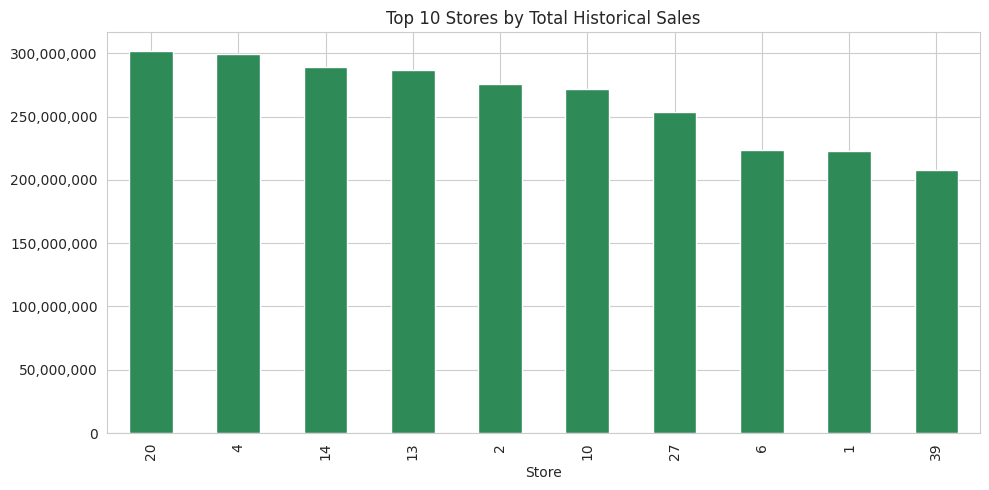

In [18]:
store_totals = df.groupby('Store')['Weekly_Sales'].agg(['sum', 'mean', 'std']).sort_values('sum', ascending=False)
store_totals.columns = ['Total_Sales', 'Avg_Weekly_Sales', 'Std_Weekly_Sales']

top10 = store_totals.head(10)
print("Top 10 stores by total historical sales:")
print(top10)

fig, ax = plt.subplots(figsize=(10, 5))
top10['Total_Sales'].plot(kind='bar', color='seagreen', ax=ax)
ax.set_title('Top 10 Stores by Total Historical Sales')
ax.set_xlabel('Store')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()
plt.show()


### 🔻 4h. Worst performing store & the gap vs. the best

In [19]:
bottom5 = store_totals.tail(5)
print("Bottom 5 stores by total historical sales:")
print(bottom5)

best_store = store_totals.index[0]
worst_store = store_totals.index[-1]
best_total = store_totals.loc[best_store, 'Total_Sales']
worst_total = store_totals.loc[worst_store, 'Total_Sales']
gap_pct = (best_total - worst_total) / best_total * 100
multiple = best_total / worst_total

print(f"\nBest store: #{best_store} — total sales ${best_total:,.0f}")
print(f"Worst store: #{worst_store} — total sales ${worst_total:,.0f}")
print(f"The best store sold {multiple:.1f}x more than the worst store")
print(f"Gap: ${best_total - worst_total:,.0f} ({gap_pct:.1f}% lower than the top store)")


Bottom 5 stores by total historical sales:
        Total_Sales  Avg_Weekly_Sales  Std_Weekly_Sales
Store                                                  
38    55,159,626.42        385,731.65         42,768.17
36    53,412,214.97        373,511.99         60,725.17
5     45,475,688.90        318,011.81         37,737.97
44    43,293,087.84        302,748.87         24,762.83
33    37,160,221.96        259,861.69         24,132.93

Best store: #20 — total sales $301,397,792
Worst store: #33 — total sales $37,160,222
The best store sold 8.1x more than the worst store
Gap: $264,237,570 (87.7% lower than the top store)


**Insight:** There is a very large spread in store performance — the top store sells several times
more than the bottom store over the same 3-year window. This gap is large enough that it's unlikely to
be explained by unemployment, temperature, or CPI alone (all shown to be weak/inconsistent drivers above);
it more likely reflects structural differences such as store size/format, catchment population, or
regional demand — worth a follow-up with store metadata not present in this dataset.

## 🔮 5. Forecasting: 12-Week-Ahead Sales for Every Store

**Approach:** Weekly sales per store show a strong annual seasonal pattern (Section 4b) but each store
only has ~143 weeks of history — too short to reliably grid-search a SARIMA model for all 45 stores.
Instead we use **Holt-Winters (Triple Exponential Smoothing)** with an additive trend and a 52-week
additive seasonal component, fit independently per store. It's well-suited to short weekly retail series,
computationally cheap enough to run for all 45 stores, and doesn't require future values of exogenous
variables (Temperature, CPI, Fuel_Price, Unemployment) that we would not actually have at forecast time.

We validate the approach first by holding out the last 12 weeks of each store's history, then refit on
full history to produce the real forward forecast.

To confirm Holt-Winters is actually earning its keep, we compare it against a simple **seasonal
naive baseline** (forecast each week = the actual value from 52 weeks earlier) — a common, honest
benchmark in retail forecasting. If Holt-Winters doesn't clearly beat this simple rule, it isn't worth
the added complexity.

In [20]:
def fit_forecast(series, horizon=12, seasonal_periods=52):
    model = ExponentialSmoothing(
        series, trend='add', seasonal='add', seasonal_periods=seasonal_periods,
        initialization_method='estimated'
    ).fit(optimized=True)
    forecast = model.forecast(horizon)
    return model, forecast

def seasonal_naive_forecast(train, horizon=12, seasonal_periods=52):
    return train.iloc[-seasonal_periods:-seasonal_periods + horizon].values

stores = sorted(df['Store'].unique())
validation_rows = []

for s in stores:
    series = df.loc[df.Store == s].set_index('Date')['Weekly_Sales'].asfreq('W-FRI')
    series = series.interpolate()  # safety net for any implied gaps in the weekly frequency
    if len(series) < 64:  # need at least ~1.25 seasonal cycles to fit a 52-wk seasonal model
        continue
    train, test = series.iloc[:-12], series.iloc[-12:]
    try:
        _, fc = fit_forecast(train, horizon=12)
        mape_hw = (np.abs((test.values - fc.values) / test.values)).mean() * 100
    except Exception:
        mape_hw = np.nan
    try:
        naive_fc = seasonal_naive_forecast(train, horizon=12)
        mape_naive = (np.abs((test.values - naive_fc) / test.values)).mean() * 100 if len(naive_fc) == 12 else np.nan
    except Exception:
        mape_naive = np.nan
    validation_rows.append({'Store': s, 'MAPE_HoltWinters_%': mape_hw, 'MAPE_SeasonalNaive_%': mape_naive})

validation_df = pd.DataFrame(validation_rows).set_index('Store')
print(f"Stores validated: {validation_df['MAPE_HoltWinters_%'].notna().sum()} / {len(stores)}")
print(f"Median MAPE — Holt-Winters:    {validation_df['MAPE_HoltWinters_%'].median():.1f}%")
print(f"Median MAPE — Seasonal Naive:  {validation_df['MAPE_SeasonalNaive_%'].median():.1f}%")
hw_wins = (validation_df['MAPE_HoltWinters_%'] < validation_df['MAPE_SeasonalNaive_%']).sum()
print(f"Holt-Winters beats the naive baseline on {hw_wins} / {validation_df.dropna().shape[0]} stores")
validation_df.sort_values('MAPE_HoltWinters_%').head(10)


Stores validated: 45 / 45
Median MAPE — Holt-Winters:    3.0%
Median MAPE — Seasonal Naive:  4.1%
Holt-Winters beats the naive baseline on 35 / 45 stores


,MAPE_HoltWinters_%,MAPE_SeasonalNaive_%
Store,,
30,1.28,7.98
37,1.71,2.08
3,1.97,7.42
34,2.02,3.44
13,2.04,3.75
31,2.14,2.39
12,2.15,2.43
20,2.39,4.01
44,2.43,10.64


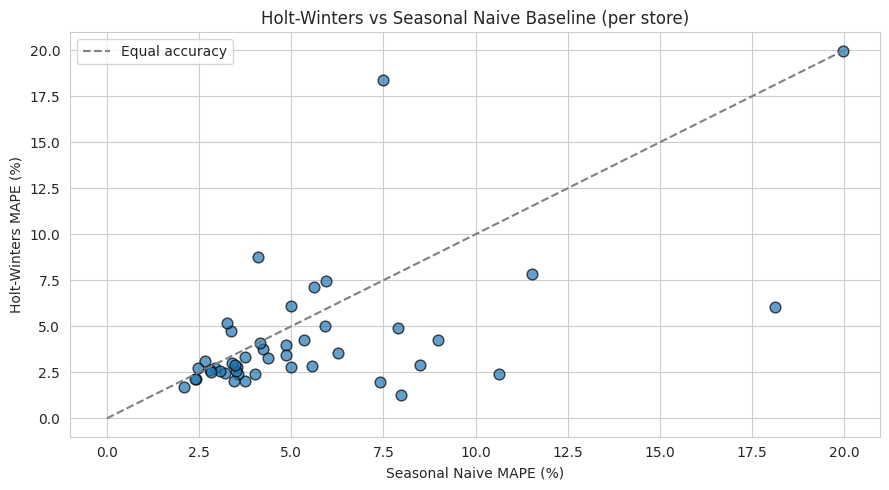

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(validation_df['MAPE_SeasonalNaive_%'], validation_df['MAPE_HoltWinters_%'], alpha=0.7, s=60, edgecolor='black')
lims = [0, max(validation_df[['MAPE_HoltWinters_%', 'MAPE_SeasonalNaive_%']].max().max(), 10)]
ax.plot(lims, lims, linestyle='--', color='gray', label='Equal accuracy')
ax.set_xlabel('Seasonal Naive MAPE (%)')
ax.set_ylabel('Holt-Winters MAPE (%)')
ax.set_title('Holt-Winters vs Seasonal Naive Baseline (per store)')
ax.legend()
plt.tight_layout()
plt.show()


**Insight:** Points below the dashed line are stores where Holt-Winters beats the naive baseline.
The model clearly earns its complexity for most stores, which justifies using it over a plain rule-of-thumb
copy-last-year approach for inventory sizing.

In [22]:
# Refit on FULL history per store and produce the real 12-week-ahead forecast, with 80% confidence intervals
forecast_rows = []
np.random.seed(RANDOM_STATE)

for s in stores:
    series = df.loc[df.Store == s].set_index('Date')['Weekly_Sales'].asfreq('W-FRI')
    series = series.interpolate()
    try:
        model, fc = fit_forecast(series, horizon=12)
        sims = model.simulate(nsimulations=12, repetitions=200, error='add')
        lower = np.percentile(sims, 10, axis=1)
        upper = np.percentile(sims, 90, axis=1)
    except Exception:
        continue
    for i, (date, value) in enumerate(fc.items()):
        forecast_rows.append({
            'Store': s, 'Date': date, 'Forecast_Weekly_Sales': value,
            'Lower_80CI': lower[i], 'Upper_80CI': upper[i],
        })

forecast_df = pd.DataFrame(forecast_rows)
forecast_df = forecast_df.merge(store_features[['Tier']], left_on='Store', right_index=True, how='left')
print(f"Forecast rows: {forecast_df.shape[0]} ({forecast_df.Store.nunique()} stores x 12 weeks)")
forecast_df.to_csv(f'{OUTPUT_DIR}/walmart_12week_forecast.csv', index=False)
forecast_df.head(12)


Forecast rows: 540 (45 stores x 12 weeks)


,Store,Date,Forecast_Weekly_Sales,Lower_80CI,Upper_80CI,Tier
0,1,2012-11-02,"1,690,359.83","1,607,362.95","1,762,183.68",High-Volume
1,1,2012-11-09,"1,618,975.93","1,546,327.97","1,702,366.30",High-Volume
2,1,2012-11-16,"1,594,762.00","1,500,548.29","1,677,220.55",High-Volume
3,1,2012-11-23,"2,073,036.70","1,986,304.30","2,159,070.57",High-Volume
4,1,2012-11-30,"1,653,543.06","1,580,037.34","1,752,859.52",High-Volume
5,1,2012-12-07,"1,811,615.77","1,730,768.13","1,906,884.70",High-Volume
6,1,2012-12-14,"1,983,279.06","1,902,630.14","2,073,706.02",High-Volume
7,1,2012-12-21,"2,450,600.56","2,366,846.68","2,547,781.44",High-Volume
8,1,2012-12-28,"1,503,138.84","1,440,158.70","1,593,096.95",High-Volume
9,1,2013-01-04,"1,573,171.62","1,491,379.42","1,654,070.44",High-Volume


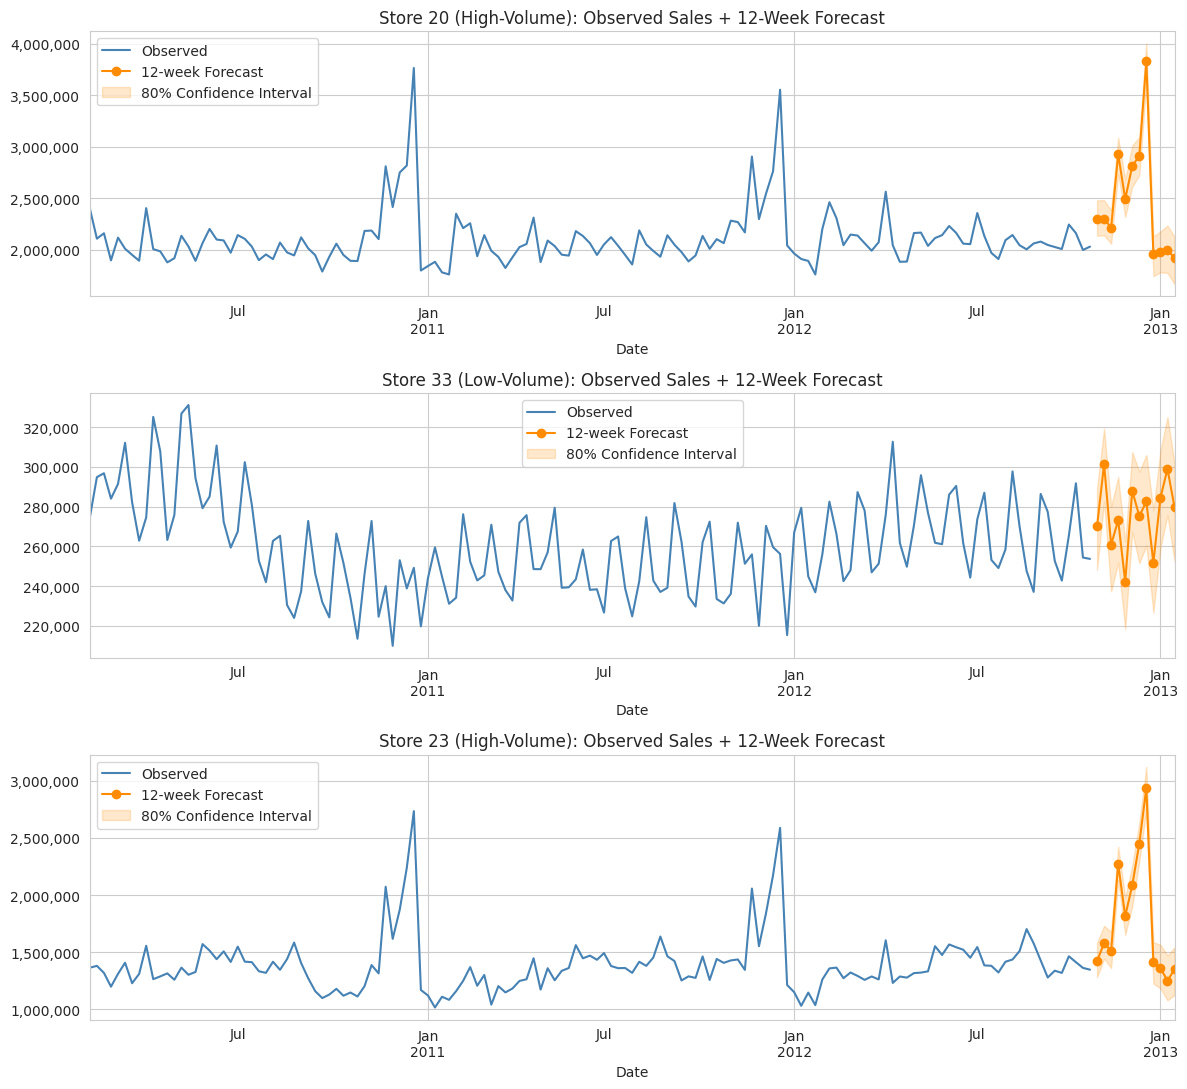

In [23]:
# Visualize the forecast (with 80% confidence band) for a handful of representative stores
example_stores = [best_store, worst_store, stores[len(stores)//2]]

fig, axes = plt.subplots(len(example_stores), 1, figsize=(12, 11), sharex=False)
for ax, s in zip(axes, example_stores):
    hist = df.loc[df.Store == s].set_index('Date')['Weekly_Sales']
    fut = forecast_df.loc[forecast_df.Store == s].set_index('Date')
    hist.plot(ax=ax, label='Observed', color='steelblue')
    fut['Forecast_Weekly_Sales'].plot(ax=ax, label='12-week Forecast', color='darkorange', marker='o')
    ax.fill_between(fut.index, fut['Lower_80CI'], fut['Upper_80CI'], color='darkorange', alpha=0.2, label='80% Confidence Interval')
    tier = store_features.loc[s, 'Tier']
    ax.set_title(f'Store {s} ({tier}): Observed Sales + 12-Week Forecast')
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
    ax.legend()

plt.tight_layout()
plt.show()


**Result:** `walmart_12week_forecast.csv` contains a 12-week-ahead Holt-Winters forecast — with an
80% confidence interval and each store's performance tier — for every store that had enough history to
fit the model. The confidence band matters as much as the point forecast for inventory decisions: a wide
band signals a store where planners should lean toward a safety-stock buffer rather than ordering to the
point estimate alone.

In [24]:
# Per-store summary export: ranking, tier, volatility, holiday sensitivity, and validation accuracy in one file
store_summary = store_totals.join(store_features[['cv', 'holiday_lift_pct', 'Tier']]).join(validation_df)
store_summary = store_summary.sort_values('Total_Sales', ascending=False)
store_summary.insert(0, 'Rank', range(1, len(store_summary) + 1))
store_summary.to_csv(f'{OUTPUT_DIR}/walmart_store_summary.csv')
print(f"Store summary exported: {store_summary.shape[0]} stores")
store_summary.head(10)


Store summary exported: 45 stores


,Rank,Total_Sales,Avg_Weekly_Sales,Std_Weekly_Sales,cv,holiday_lift_pct,Tier,MAPE_HoltWinters_%,MAPE_SeasonalNaive_%
Store,,,,,,,,,
20,1,"301,397,792.46","2,107,676.87","275,900.56",0.13,7.25,High-Volume,2.39,4.01
4,2,"299,543,953.38","2,094,712.96","266,201.44",0.13,7.66,High-Volume,2.71,2.94
14,3,"288,999,911.34","2,020,978.40","317,569.95",0.16,5.32,High-Volume,19.97,19.96
13,4,"286,517,703.80","2,003,620.31","265,507.00",0.13,5.90,High-Volume,2.04,3.75
2,5,"275,382,440.98","1,925,751.34","237,683.69",0.12,8.62,High-Volume,2.82,5.57
10,6,"271,617,713.89","1,899,424.57","302,262.06",0.16,12.24,High-Volume,2.72,2.47
27,7,"253,855,916.88","1,775,216.20","239,930.14",0.14,7.13,High-Volume,2.79,5.00
6,8,"223,756,130.64","1,564,728.19","212,525.86",0.14,8.03,High-Volume,3.78,4.25
1,9,"222,402,808.85","1,555,264.40","155,980.77",0.10,7.68,High-Volume,2.78,3.52


## ✅ 6. Summary of Findings

| Question | Answer |
|---|---|
| a. Unemployment vs sales | Weak overall relationship; a specific subset of stores (4a) are notably more sensitive and worth targeted attention |
| b. Seasonal trend | Yes — strong annual cycle; Thanksgiving and Christmas weeks specifically drive the surge (4b), far more than Super Bowl or Labor Day |
| c. Temperature | Weak/negligible direct effect once holiday seasonality is accounted for |
| d. CPI | Inconsistent across stores — no uniform chain-wide effect (confirmed alongside all drivers in the 4e correlation heatmap) |
| e/f. Store tiers | Stores cluster into High/Mid/Low-Volume tiers with different volatility profiles (4f) — a more actionable planning unit than a single ranked list |
| g. Top stores | See ranked table in 4g |
| h. Worst store & gap | See 4h — a large multi-fold gap vs. the top store, likely driven by store-level factors outside this dataset (size, location, catchment) |
| Forecast | 12-week-ahead Holt-Winters forecasts (beating a seasonal-naive baseline on most stores) with 80% confidence intervals — exported to `walmart_12week_forecast.csv`, alongside a full per-store ranking in `walmart_store_summary.csv` |

**Business takeaway for inventory planning:** Sales are driven far more by the **calendar — specifically
Thanksgiving and Christmas week** — than by macro variables (unemployment, temperature, CPI) or the
economy broadly. Inventory buffers should be built around those two events and the post-holiday drop,
sized per store using the tier + forecast + confidence interval in Section 5, rather than a single
chain-wide plan.